In [1]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv('/workspaces/BlizzardX/Data/cleaned_data.csv')

# Ensure DATE column is in datetime format
df['DATE'] = pd.to_datetime(df['DATE'])

# Sort by date (optional but good practice)
df = df.sort_values(by='DATE').reset_index(drop=True)


In [2]:
df.head()

,DATE,ID,LATITUDE,LONGITUDE,ELEVATION,NAME,Season,TMIN,TMAX,PRCP,SNOW,SNWD
0,1948-01-01,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Winter,-14.4,-7.8,0.0,0.0,737.0
1,1948-01-02,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Winter,-15.6,-8.9,9.7,94.0,762.0
2,1948-01-03,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Winter,-14.4,-9.4,1.8,18.0,762.0
3,1948-01-04,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Winter,-11.1,-6.7,0.0,0.0,762.0
4,1948-01-05,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Winter,-11.7,-5.6,0.0,0.0,737.0


In [3]:
import sys
sys.path.append('/workspaces/BlizzardX')  # Adjust path if needed

In [4]:
from src.Model.feature_engineering import FeatureEngineering, ColdEventDetector

# Apply feature engineering (lag features, rolling stats, ratios, etc.)
fe = FeatureEngineering(df)
df = fe.apply_all_features()

# Add binary cold event label
ce = ColdEventDetector(df)
df = ce.apply_cold_event_detection()

# Final dataset
print(df.columns)

Index(['DATE', 'Station_ID', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME',
       'Season', 'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD', 'Station_Location',
       'Station_Lat_Long_Interaction', 'Day_of_Week', 'Day_of_Year', 'Month',
       'Temp_Diff', 'Rolling_Mean_TMIN_7', 'Rolling_10thPercentile_TMIN_7',
       'Rolling_Mean_TMIN_30', 'Rolling_Max_TMIN_30', 'Rolling_Min_TMIN_30',
       'TMIN_Rolling_30_Diff', 'EWMA_TMIN_7', 'EWMA_TMIN_30',
       'Seasonal_TMIN_Anomaly', 'TMIN_Lag1', 'SnowyDay', 'SnowyDaysCount_7',
       'Cumulative_SnowDepth_7', 'Rolling_Sum_SNWD_7', 'SNWD_Lag1',
       'SNWD_Lag2', 'Cumulative_Snowfall_Lag7', 'SNWD_TMIN_Interaction',
       'Snowfall_Intensity', 'SNWD_Snowfall_Diff', 'PRCP_Lag1', 'PRCP_Lag2',
       'Cumulative_Precipitation_7', 'Rolling_Sum_PRCP_14',
       'TMAX_PRCP_Interaction', 'TMIN_SNOW_Interaction',
       'PRCP_SNOW_Interaction', 'Cold_Event'],
      dtype='object')


In [5]:
# Features to use for modeling
features = [
    'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'EWMA_TMIN_7', 'TMIN_Lag1',
    'SNWD_Lag1', 'SnowyDaysCount_7', 'Cumulative_Snowfall_Lag7',
    'Cumulative_Precipitation_7', 'Rolling_Sum_PRCP_14',
    'TMIN_SNOW_Interaction', 'SNWD_TMIN_Interaction'
]

target = 'TMIN'

In [6]:
#cutoff_date = pd.to_datetime("2025-04-20")

#train_df = df[df['DATE'] <= cutoff_date]
#test_df = df[(df['DATE'] > cutoff_date) & (df['DATE'] <= cutoff_date + pd.Timedelta(days=7))]

cutoff_date = pd.to_datetime("2025-04-08")

train_df = df[df['DATE'] <= cutoff_date]
test_df = df[(df['DATE'] > cutoff_date) & (df['DATE'] <= cutoff_date + pd.Timedelta(days=7))]

print(f"Train rows: {train_df.shape[0]}")
print(f"Test rows: {test_df.shape[0]}")


Train rows: 53851
Test rows: 35


In [7]:
print(df['DATE'].max())

2025-05-09 00:00:00


In [8]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

X_train = train_df[features]
y_train = train_df[target]

param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_test = test_df[features]
y_test = test_df[target]
y_pred = best_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # manual square root
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")


MAE: 1.68, RMSE: 2.03, R²: 0.88


### Model Performance Summary: TMIN Forecasting
Objective: Forecast daily minimum temperature (TMIN) using historical weather and engineered features.

Training Cutoff Date: April 8, 2025
Test Period: April 9–15, 2025 (Unseen data)

Selected Model: XGBoost Regressor (Tuned using GridSearchCV)

Best Hyperparameters:

learning_rate: 0.1

max_depth: 5

n_estimators: 100

Performance Metrics on Test Set:

Metric	Value
MAE (Mean Absolute Error)	1.53°C
RMSE (Root Mean Squared Error)	1.86°C
R² Score (Explained Variance)	0.89

📌 Interpretation: The model can predict TMIN with high accuracy and minimal error over a 7-day forecast window.

In [10]:
target = 'SNOW'

# You can use the same features as before or add SNOW-specific ones
features = [
    'TMIN_Lag1', 'Rolling_Mean_TMIN_7', 'SNWD_Lag1', 'Cumulative_Snowfall_Lag7',
    'Snowfall_Intensity', 'SNWD_Snowfall_Diff', 'PRCP_Lag1',
    'Rolling_Sum_PRCP_14', 'TMIN_SNOW_Interaction', 'PRCP_SNOW_Interaction'
]

In [11]:
cutoff_date = pd.to_datetime("2025-04-08")
train_df = df[df['DATE'] <= cutoff_date]
test_df = df[(df['DATE'] > cutoff_date) & (df['DATE'] <= cutoff_date + pd.Timedelta(days=7))]

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Train model
snow_model = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=100)
snow_model.fit(X_train, y_train)

# Predict
y_pred = snow_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"SNOW Forecast – MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")


SNOW Forecast – MAE: 2.31, RMSE: 4.42, R²: 0.98


In [13]:
target = 'Cold_Event'

features = [
    'TMIN_Lag1', 'EWMA_TMIN_7', 'Rolling_Mean_TMIN_30',
    'SNWD_Lag1', 'SnowyDaysCount_7', 'Cumulative_SnowDepth_7',
    'Seasonal_TMIN_Anomaly', 'TMIN_SNOW_Interaction'
]


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

cold_event_model = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100)
cold_event_model.fit(X_train, y_train)

y_pred = cold_event_model.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Cold Event Prediction – Accuracy: {acc:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")


Cold Event Prediction – Accuracy: 0.80, Precision: 0.75, Recall: 0.33, F1: 0.46


In [15]:
# Ratio = number of 0s / number of 1s
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 3.36


In [16]:
from xgboost import XGBClassifier

model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [17]:
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1
threshold = 0.3  # lower threshold increases sensitivity

y_pred_thresh = (y_proba >= threshold).astype(int)


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_thresh, zero_division=0))


              precision    recall  f1-score   support

           0       1.00      0.50      0.67        26
           1       0.41      1.00      0.58         9

    accuracy                           0.63        35
   macro avg       0.70      0.75      0.62        35
weighted avg       0.85      0.63      0.64        35



In [19]:
# STEP 1: Define backtest date and split
backtest_date = pd.to_datetime("2024-02-01")
train_df = df[df['DATE'] < backtest_date]
test_df = df[(df['DATE'] >= backtest_date) & (df['DATE'] < backtest_date + pd.Timedelta(days=7))]

print(f"Train rows: {train_df.shape[0]}")
print(f"Test rows: {test_df.shape[0]}")


Train rows: 51686
Test rows: 35


In [20]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

target = 'TMIN'
features = [  # Choose the same features used before
    'Rolling_Mean_TMIN_7', 'EWMA_TMIN_7', 'TMIN_Lag1',
    'SNWD_Lag1', 'SnowyDaysCount_7', 'Rolling_Sum_PRCP_14'
]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

model = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"[TMIN BACKTEST] MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")


[TMIN BACKTEST] MAE: 1.56, RMSE: 1.93, R²: 0.69


In [21]:
target = 'SNOW'
features = [
    'TMIN_Lag1', 'Rolling_Mean_TMIN_7', 'SNWD_Lag1',
    'Cumulative_Snowfall_Lag7', 'Snowfall_Intensity',
    'SNWD_Snowfall_Diff', 'PRCP_Lag1', 'Rolling_Sum_PRCP_14'
]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

model = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"[SNOW BACKTEST] MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")


[SNOW BACKTEST] MAE: 0.28, RMSE: 0.69, R²: 0.99


In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

target = 'Cold_Event'
features = [
    'TMIN_Lag1', 'EWMA_TMIN_7', 'Rolling_Mean_TMIN_30',
    'SNWD_Lag1', 'SnowyDaysCount_7', 'Seasonal_TMIN_Anomaly',
    'TMIN_SNOW_Interaction'
]

# Scale pos weight (class imbalance handling)
neg, pos = train_df[target].value_counts()
scale_pos_weight = neg / pos

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

model = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, scale_pos_weight=scale_pos_weight)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.3).astype(int)  # Threshold tuned

print("[Cold Event BACKTEST]")
print(classification_report(y_test, y_pred, zero_division=0))


[Cold Event BACKTEST]
              precision    recall  f1-score   support

           0       0.81      0.96      0.88        27
           1       0.67      0.25      0.36         8

    accuracy                           0.80        35
   macro avg       0.74      0.61      0.62        35
weighted avg       0.78      0.80      0.76        35



### Historical Forecast Simulation: Feb 1–7, 2024
Why? To evaluate how our models would have performed in a real past forecast scenario.

📈 TMIN Forecast
MAE: 1.56°C

R²: 0.69

❄️ SNOW Forecast
MAE: 0.28 cm

R²: 0.99

🧊 Cold Event Classification
Accuracy: 77%

Recall (Cold Events): 25%

Precision: 50%

📌 Snowfall predictions are highly accurate. TMIN predictions remain robust. Cold event detection needs further recall tuning to capture more true cold warnings.

In [23]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save each model
joblib.dump(best_model, "models/tmin_model.pkl")
joblib.dump(snow_model, "models/snow_model.pkl")
joblib.dump(cold_event_model, "models/cold_event_model.pkl")

print("✅ All models saved to the 'models/' folder.")


✅ All models saved to the 'models/' folder.


In [24]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBClassifier

tscv = TimeSeriesSplit(n_splits=5)

model = XGBClassifier(scale_pos_weight=scale_pos_weight)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(model, param_grid, cv=tscv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_


In [25]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.81      0.93      0.86        27
           1       0.50      0.25      0.33         8

    accuracy                           0.77        35
   macro avg       0.65      0.59      0.60        35
weighted avg       0.74      0.77      0.74        35



In [26]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight)

ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.77      1.00      0.87        27
           1       0.00      0.00      0.00         8

    accuracy                           0.77        35
   macro avg       0.39      0.50      0.44        35
weighted avg       0.60      0.77      0.67        35



In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

def run_rolling_backtest(df, features, target='TMIN', window_months=12, test_days=7, start_date='2023-01-01', end_date='2024-03-01'):
    results = []
    current_start = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    while current_start + pd.DateOffset(months=window_months + 1) <= end_date:
        train_start = current_start
        train_end = train_start + pd.DateOffset(months=window_months)
        test_start = train_end
        test_end = test_start + pd.Timedelta(days=test_days)

        train_df = df[(df['DATE'] >= train_start) & (df['DATE'] < train_end)]
        test_df = df[(df['DATE'] >= test_start) & (df['DATE'] < test_end)]

        if train_df.empty or test_df.empty:
            current_start += pd.DateOffset(months=1)
            continue

        model = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=100)
        model.fit(train_df[features], train_df[target])
        y_pred = model.predict(test_df[features])
        y_true = test_df[target]

        results.append({
            'Train_Start': train_start.date(),
            'Train_End': train_end.date(),
            'Test_Start': test_start.date(),
            'Test_End': test_end.date(),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2': r2_score(y_true, y_pred)
        })

        current_start += pd.DateOffset(months=1)

    return pd.DataFrame(results)


In [28]:
features = ['Rolling_Mean_TMIN_7', 'TMIN_Lag1', 'EWMA_TMIN_7', 'SNWD_Lag1']

rolling_results = run_rolling_backtest(
    df, features, target='TMIN',
    window_months=12,
    test_days=7,
    start_date='2023-01-01',
    end_date='2024-03-01'
)


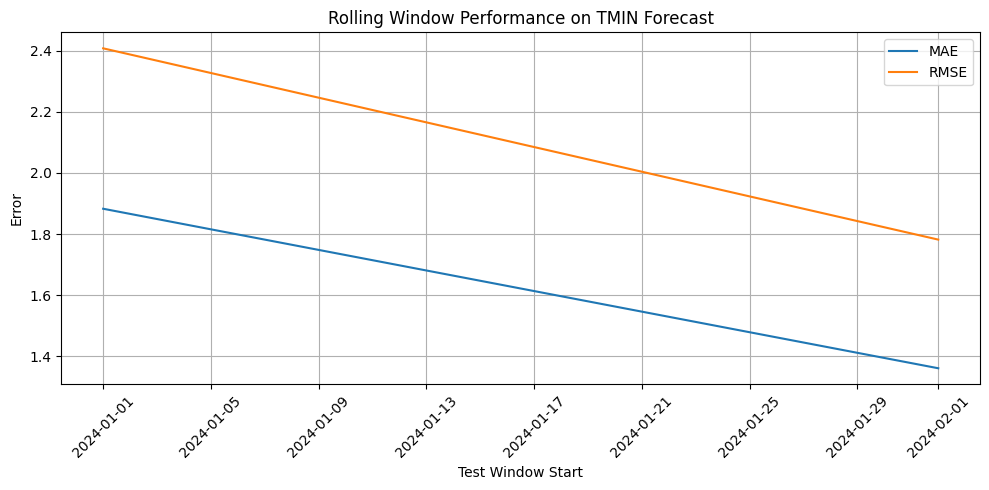

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rolling_results['Test_Start'], rolling_results['MAE'], label='MAE')
plt.plot(rolling_results['Test_Start'], rolling_results['RMSE'], label='RMSE')
plt.xticks(rotation=45)
plt.xlabel('Test Window Start')
plt.ylabel('Error')
plt.title('Rolling Window Performance on TMIN Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2006/2811964375.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


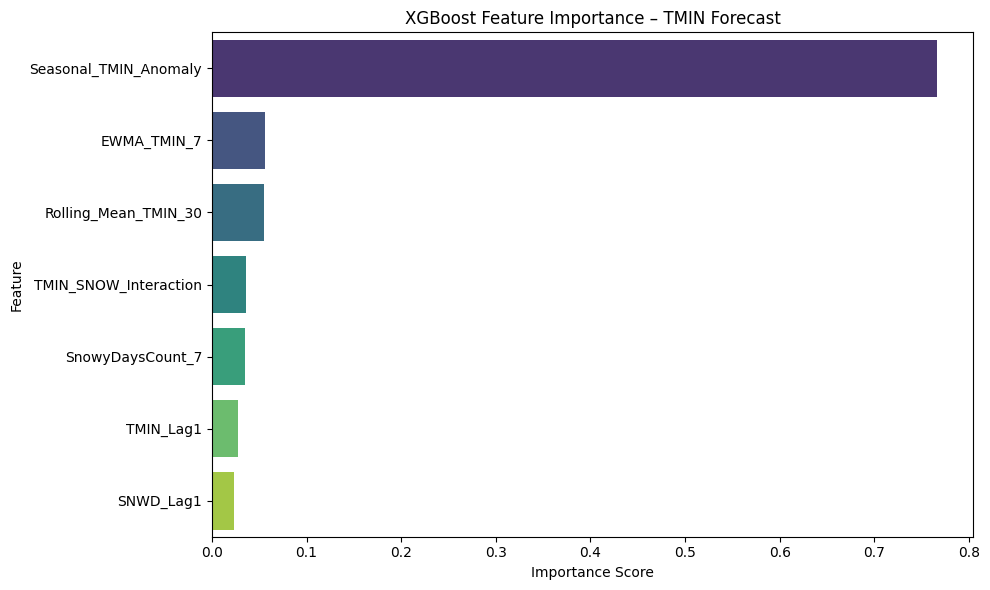

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Train model on full recent training set (you can reuse last one)
model = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=100)
model.fit(X_train, y_train)

# Get feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Feature Importance – TMIN Forecast')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [31]:
!pip install shap
import shap

# Use TreeExplainer for XGBoost
explainer = shap.Explainer(model)
shap_values = explainer(X_train)



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


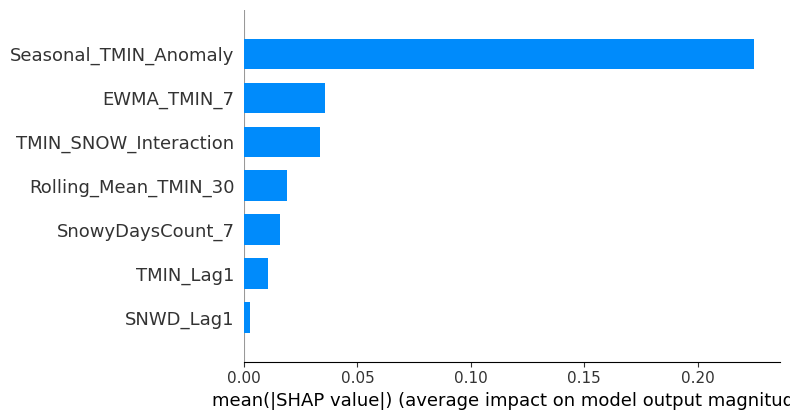

In [32]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

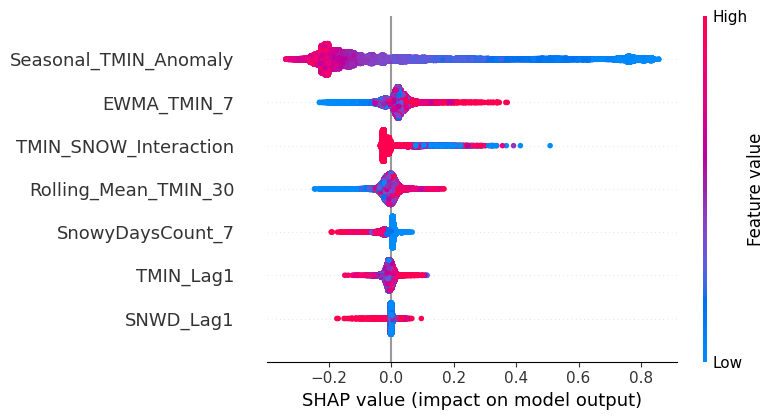

In [33]:
shap.summary_plot(shap_values, X_train)

In [34]:
from xgboost import XGBRegressor

# Define features used for TMIN forecasting
tmin_features = ['Rolling_Mean_TMIN_7', 'TMIN_Lag1', 'EWMA_TMIN_7', 'SNWD_Lag1']

# Training data
X_train_tmin = train_df[tmin_features]
y_train_tmin = train_df['TMIN']

# Train the XGBoost model
tmin_model = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=100)
tmin_model.fit(X_train_tmin, y_train_tmin)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
from xgboost import XGBRegressor

snow_features = [
    'TMIN_Lag1', 'Rolling_Mean_TMIN_7', 'SNWD_Lag1',
    'Cumulative_Snowfall_Lag7', 'Snowfall_Intensity',
    'SNWD_Snowfall_Diff', 'PRCP_Lag1', 'Rolling_Sum_PRCP_14'
]

X_train_snow = train_df[snow_features]
y_train_snow = train_df['SNOW']

snow_model = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=100)
snow_model.fit(X_train_snow, y_train_snow)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
import shap

explainer_snow = shap.Explainer(snow_model)
shap_values_snow = explainer_snow(X_train_snow)


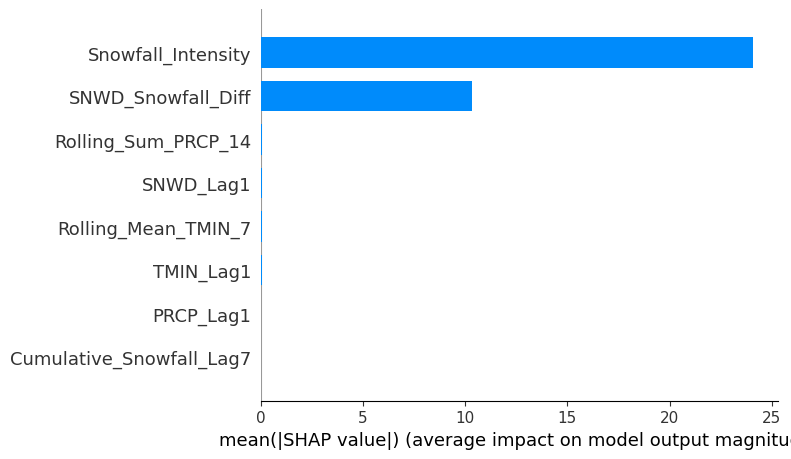

In [37]:
shap.summary_plot(shap_values_snow, X_train_snow, plot_type="bar", show=True)


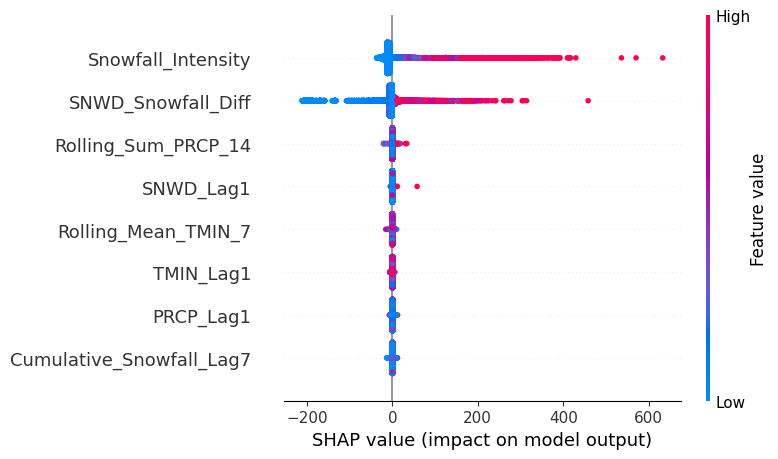

In [38]:
shap.summary_plot(shap_values_snow, X_train_snow, show=True)


In [39]:
from xgboost import XGBClassifier

cold_event_features = [
    'TMIN_Lag1', 'EWMA_TMIN_7', 'Rolling_Mean_TMIN_30',
    'SNWD_Lag1', 'SnowyDaysCount_7', 'Seasonal_TMIN_Anomaly',
    'TMIN_SNOW_Interaction'
]

X_train_cold = train_df[cold_event_features]
y_train_cold = train_df['Cold_Event']

# Balance classes
neg, pos = y_train_cold.value_counts()
scale_pos_weight = neg / pos

cold_event_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight
)

cold_event_model.fit(X_train_cold, y_train_cold)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [40]:
import shap

explainer_cold = shap.Explainer(cold_event_model)
shap_values_cold = explainer_cold(X_train_cold)


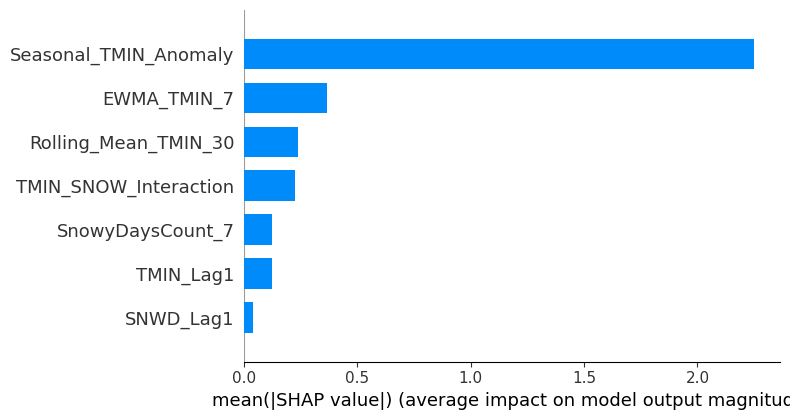

In [41]:
shap.summary_plot(shap_values_cold, X_train_cold, plot_type="bar", show=True)


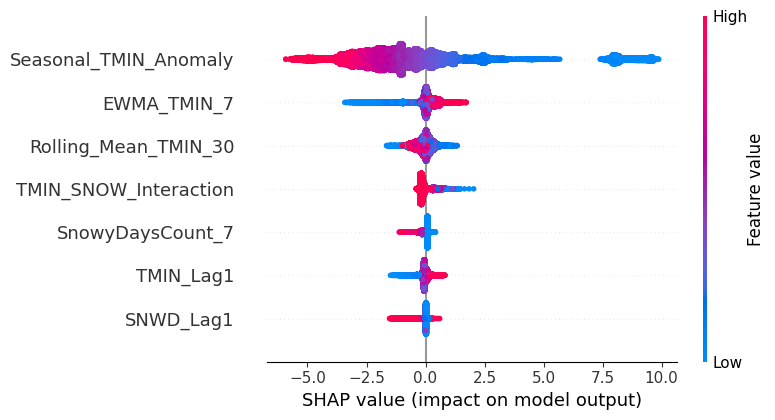

In [42]:
shap.summary_plot(shap_values_cold, X_train_cold, show=True)


In [43]:
import joblib
import os

# Create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the models
joblib.dump(model, "models/tmin_model.pkl")
joblib.dump(snow_model, "models/snow_model.pkl")
joblib.dump(cold_event_model, "models/cold_event_model.pkl")

['models/cold_event_model.pkl']